In [1]:
# import packages
%load_ext autoreload
%autoreload 2
import os
import sys


sys.path.append(".")
sys.path.append("..")
sys.path.append("../scripts")

import torch
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
# from torchvision.utils import save_image
from dit4science.model.dit_diffusion import create_diffusion
from download import find_model  # noqa
from dit4science.model.dit_models import DiT_models
import argparse
import numpy as np

from torchvision import transforms
import matplotlib.pyplot as plt
from dit4science.data.dataset_dit import TurbDataset
from torch.utils.data import DataLoader
from dit4science.utils.bench import get_error, plot_error_curve
from dit4science.model.autoencoder import AutoencoderKL

/home/chunyang/miniconda3/envs/DiT/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/chunyang/miniconda3/envs/DiT/lib/python3.12/site-packages/diffusers/models/transformers/transformer_2d.py:34: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)


In [2]:
device = "cuda:3" if torch.cuda.is_available() else "cpu"
# vae = AutoencoderKL.from_pretrained(f"stabilityai/sd-vae-ft-ema").to(device)

# Autoencoder config
config = {
    "monitor": "val/rec_loss",
    "embed_dim": 4,
    "lossconfig": {
        "target": "ldm.modules.losses.LPIPSWithDiscriminator",
        "params": {
            "disc_start": 50001,
            "kl_weight": 0.000001,
            "disc_weight": 0.5
        }
    },
    "ddconfig": {
        "double_z": True,
        "z_channels": 4,
        "resolution": 256,
        "in_channels": 3,
        "out_ch": 3,
        "ch": 128,
        "ch_mult": [1, 2, 4, 4],  # num_down = len(ch_mult) - 1
        "num_res_blocks": 2,
        "attn_resolutions": [],
        "dropout": 0.0
    }
}
vae_ckpt = "/home/chunyang/projects/ai4science/latent-diffusion/logs/idx0-2024-08-14T11-14-30_channel_idx_0_autoencoder_kl_32x32x4_c_0/testtube/version_0/checkpoints/epoch=114-step=126154.ckpt"
vae = AutoencoderKL(**config).to(device)
vae.init_from_ckpt(vae_ckpt)

def plot_fiels(data, ground):
    """
    data is of shape: (batch, channel, H, W).
    """
    # vmin = -0.1
    # vmax = 1
    bs, c, H, W = data.shape
    data = data.detach().cpu().numpy()
    ground = ground.detach().cpu().numpy()
    error = np.abs(data - ground)
    reso = 5
    fig, axs = plt.subplots(c, bs*3, figsize=(reso*bs*3, reso*c))
    for k in range(3):
        for i in range(c):
            for j in range(bs):
                if (k == 0):
                    # axs[i][j*3].imshow(data[j, i, :, :], cmap="jet", interpolation="catrom", vmin=vmin, vmax=vmax)
                    axs[i][j*3].imshow(data[j, i, :, :], cmap="jet", interpolation="catrom")
                if (k == 1):
                    # axs[i][j*3+1].imshow(ground[j, i, :, :], cmap="jet", interpolation="catrom", vmin=vmin, vmax=vmax)
                    axs[i][j*3+1].imshow(ground[j, i, :, :], cmap="jet", interpolation="catrom")
                if (k == 2):
                    axs[i][j*3+2].imshow(error[j, i, :, :])
    return fig, axs

making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels


/home/chunyang/miniconda3/envs/DiT/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/chunyang/miniconda3/envs/DiT/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth
Restored from /home/chunyang/projects/ai4science/latent-diffusion/logs/idx0-2024-08-14T11-14-30_channel_idx_0_autoencoder_kl_32x32x4_c_0/testtube/version_0/checkpoints/epoch=114-step=126154.ckpt


In [8]:

# args:
channel_idx=0
patch_size=2
seed = 1
image_size=128
model=f"DiT-B/{patch_size}"
num_sampling_steps=250
data_path="/home/chunyang/projects/ai4science/DDPM4Science/data/test/"
# data_path="/home/chunyang/projects/ai4science/DDPM4Science/data/train_6k/"
# ckpt="/home/chunyang/projects/ai4science/DDPM4Science/results/009-DiT-B-8/checkpoints/0048000.pt"  # run finished on 6k, patch size = 8

ckpt="/home/chunyang/projects/ai4science/DiT4Science/results/033-DiT-B-2-channel_idx0/checkpoints/2100000.pt"  # on 6k, idx=0


num_classes=1000
cfg_scale=40

# Setup PyTorch:
torch.manual_seed(seed)
torch.set_grad_enabled(False)

if ckpt is None:
    assert model == "DiT-XL/2", "Only DiT-XL/2 models are available for auto-download."
    assert image_size in [256, 512]
    assert num_classes == 1000

############ VAE init ###################

# Load model:
latent_size = image_size // 8
model = DiT_models[model](
        is_latent_cond=True,
        input_size=latent_size,
        # input_size=args.image_size,
        num_classes=num_classes,
        in_channels=4,
        cond_channels=3,
        cond_size=128,
).to(device)
# Auto-download a pre-trained model or load a custom DiT checkpoint from train.py:
ckpt_path = ckpt
state_dict = find_model(ckpt_path)
model.load_state_dict(state_dict)
model.eval()  # important!

########### DATASET ##################################################################
batch_size = 72
# transform = transforms.Compose([
#     transforms.Lambda(lambda pil_image: center_crop_arr(pil_image, args.image_size)),
#     transforms.RandomHorizontalFlip(),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=True)
# ])
prop=None
dataset = TurbDataset(dataProp=prop, dataDir=data_path, gaussian_norm=False, channel_idx=channel_idx)
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
    drop_last=True
)
input_data = next(iter(loader))
x, ground = input_data
x = x.to(device)
ground = ground.to(device)
# y = y.to(device)
# print(input_data)
# print("len", len(input_data))
# print("jiji", type(input_data[0]), type(input_data[1]))
# print("kiki", input_data[0].shape, input_data[1].shape)
#######################################################################################


########## Data UPSCALE ###############################################################
upsample = torch.nn.Upsample(scale_factor=2)
#######################################################################################

diffusion = create_diffusion(str(num_sampling_steps))

# Labels to condition the model with (feel free to change):
# class_labels = [1, 2, 3, 4, 5, 6, 7, 8]

# Create sampling noise:
# n = len(class_labels)
# y = upsample(x)
# y = vae.encode(y).latent_dist.sample()
# with torch.no_grad():
#     # Map input images to latent space + normalize latents:
#     y = vae.encode(x).sample()
y = x.to(device)
# ground = upsample(ground)
# ground = vae.decode(
#     vae.encode(ground).latent_dist.sample()
# ).sample
n = batch_size
# z = torch.randn(n, 4, latent_size, latent_size, device=device)
z = torch.randn(n, 4, latent_size, latent_size, device=device)
# y = torch.tensor(class_labels, device=device)

# Setup classifier-free guidance:
# z = torch.cat([z, z], 0)
# y_null = torch.zeros_like(y, device=device)
# y = torch.cat([y, y_null], 0)
model_kwargs = dict(y=y)

# Sample images:
# samples = diffusion.p_sample_loop(
#     model.forward_with_cfg, z.shape, z, clip_denoised=False,
#     model_kwargs=model_kwargs, progress=True, device=device
# )
samples = diffusion.p_sample_loop(
    model.forward, z.shape, z, clip_denoised=False,
    model_kwargs=model_kwargs, progress=True, device=device
)

samples = vae.decode(samples)

# samples, _ = samples.chunk(2, dim=0)  # Remove null class samples
# ground, _ = ground.chunk(2, dim=0)

# samples = vae.decode(samples).sample
error_p = get_error(samples[:, 0, :, :], ground[:, 0, :, :])
error_ux = get_error(samples[:, 1, :, :], ground[:, 1, :, :])
error_uy = get_error(samples[:, 2, :, :], ground[:, 2, :, :])

print("error_p, error_ux, error_uy", error_p, error_ux, error_uy)
# fig, axs = plot_fiels(samples, ground)
plt.show()

Number of test loaded: 90
Using fixed maxima [4.65, 2.04, 2.37]
Data stats, input  mean 0.190220, max  0.961052;   targets mean 0.289502 , max 1.000000 


100%|██████████| 250/250 [00:21<00:00, 11.76it/s]


error_p, error_ux, error_uy tensor(0.1136, device='cuda:3') tensor(0.1137, device='cuda:3') tensor(0.1134, device='cuda:3')


In [ ]:
%%timeit

samples = diffusion.p_sample_loop(
    model.forward, z.shape, z, clip_denoised=False,
    model_kwargs=model_kwargs, progress=True, device=device
)

  4%|▎         | 9/250 [00:00<00:03, 76.40it/s]

100%|██████████| 250/250 [00:03<00:00, 68.26it/s]

3.66 s ± 11.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


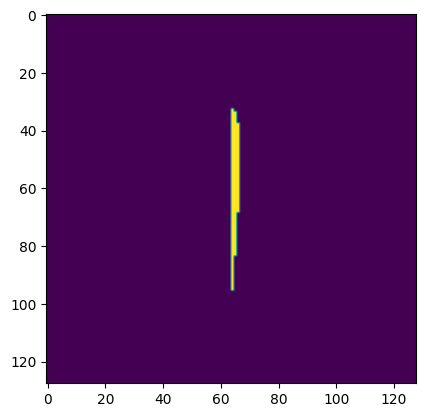

In [21]:
plt.imshow(x.detach().cpu().numpy()[0, 2, :, :])